In [26]:
# Connect to Postgres
%matplotlib inline
%pip install xgboost
import os
import psycopg2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc


def newCursor():
    try:
        connection = psycopg2.connect(
            user=os.environ["DB_USER"],
            host=os.environ["DB_HOST"],
            password=os.environ["DB_PASSWORD"],
            port="5432",
            database=os.environ["DB_DATABASE"]
        )

        cursor = connection.cursor()
        return cursor

    except (Exception, psycopg2.Error) as error:
        print("Error while connecting to PostgreSQL", error)
        return error


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
# Test database connection

cursor = newCursor()

if isinstance(cursor, psycopg2.extensions.cursor):
    cursor.execute("SELECT version();")
    db_version = cursor.fetchone()
    print("✅ Successfully connected to PostgreSQL")
    print("Database version:", db_version[0])
else:
    print("❌ Connection failed. Please check environment configuration.")


✅ Successfully connected to PostgreSQL
Database version: PostgreSQL 16.8 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 7.3.1 20180712 (Red Hat 7.3.1-17), 64-bit


In [28]:
# Featured Challenge Tables

FEATURED_TABLES = [
    "D01_transactions_2024-01",
    "D01_transactions_2024-02",
    "D01_transactions_2024-03",
    "D01_transactions_2024-04",
    "D01_transactions_2024-05",
    "D01_transactions_2024-06",
    "D01_transactions_2024-07",
    "D01_transactions_2024-08",
    "D01_transactions_2024-09",
    "D01_transactions_2024-10",
    "D01_transactions_2024-11",
    "D01_transactions_2024-12",
    "D02_payment_instruments",
    "D03_settlement_logs",
    "D04_fraud_events",
    "D05_system_outages",
    "D06_psps",
    "D07_access_channels",
    "D08_cross_border_sepa",
    "D09_macro_aggregates",
    "D10_profiles",
]

print("⭐ Featured Tables loaded:", len(FEATURED_TABLES))


⭐ Featured Tables loaded: 21


In [29]:
# Fetch tables and validate featured tables

from collections import defaultdict

c = newCursor()

q = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_type = 'BASE TABLE'
"""
c.execute(q)
records = c.fetchall()

user_records = [
    (schema, table) for schema, table in records
    if schema not in ("pg_catalog", "information_schema")
]

schemas_by_table = defaultdict(list)
for schema, table in user_records:
    schemas_by_table[table].append(schema)

TABLE_LOOKUP = {
    table: f"{schemas[0]}.{table}"
    for table, schemas in schemas_by_table.items()
}

print("🔎 Checking Featured Tables...\n")

found = 0
for table in FEATURED_TABLES:
    if table in TABLE_LOOKUP:
        print(f"✅ {table}")
        found += 1
    else:
        print(f"❌ {table} (not found)")

print(f"\nMatched {found} out of {len(FEATURED_TABLES)} featured tables.")


🔎 Checking Featured Tables...

✅ D01_transactions_2024-01
✅ D01_transactions_2024-02
✅ D01_transactions_2024-03
✅ D01_transactions_2024-04
✅ D01_transactions_2024-05
✅ D01_transactions_2024-06
✅ D01_transactions_2024-07
✅ D01_transactions_2024-08
✅ D01_transactions_2024-09
✅ D01_transactions_2024-10
✅ D01_transactions_2024-11
✅ D01_transactions_2024-12
✅ D02_payment_instruments
✅ D03_settlement_logs
✅ D04_fraud_events
✅ D05_system_outages
✅ D06_psps
✅ D07_access_channels
✅ D08_cross_border_sepa
✅ D09_macro_aggregates
✅ D10_profiles

Matched 21 out of 21 featured tables.


In [30]:
# List all tables

c = newCursor()

q = """
SELECT table_name
FROM information_schema.tables
"""
c.execute(q)
records = c.fetchall()

# Filter out PostgreSQL system tables
user_tables = [
    r[0] for r in records
    if not r[0].startswith("pg_")
]

if not user_tables:
    print("❌ No user tables found.")
else:
    print(f"📚 Total user tables found: {len(user_tables)}\n")
    for table in user_tables:
        print("-", table)


📚 Total user tables found: 691

- q_airport_distance
- stocks_yahoo_finance
- q_ApprovalRequest
- default
- accounts
- card2
- cards
- q_airportdistance
- channel
- audit_log_schema
- clients
- q_approvalrequest
- collations
- information_schema_catalog_name
- applicable_roles
- domain_constraints
- administrable_role_authorizations
- collation_character_set_applicability
- attributes
- character_sets
- column_udt_usage
- check_constraint_routine_usage
- column_column_usage
- check_constraints
- constraint_table_usage
- column_domain_usage
- columns
- column_privileges
- constraint_column_usage
- domain_udt_usage
- domains
- enabled_roles
- key_column_usage
- parameters
- table_privileges
- referential_constraints
- sql_features
- role_column_grants
- routine_column_usage
- routine_privileges
- role_routine_grants
- routine_routine_usage
- routine_sequence_usage
- routine_table_usage
- routines
- schemata
- sequences
- role_table_grants
- table_constraints
- triggers
- tables
- trigger

# Importing the data

In [31]:
# Preview rows from a selected table

from psycopg2 import sql

# ✅ Choose a table
TABLE = "D04_fraud_events"  # change index e.g. FEATURED_TABLES[3]
LIMIT = 1000

if TABLE not in TABLE_LOOKUP:
    raise ValueError(f'❌ Table "{TABLE}" not found. Run Section 2 cells first.')

# Get schema + table name internally
schema, table_name = TABLE_LOOKUP[TABLE].split(".", 1)

c = newCursor()

# Safe query (handles schema + hyphenated table names correctly)
query = sql.SQL("SELECT * FROM {}.{}").format(
    sql.Identifier(schema),
    sql.Identifier(table_name)
)

c.execute(query, (LIMIT,))
rows = c.fetchall()

# Column names
colnames = [desc[0] for desc in c.description]

print(f"📄 Table: {TABLE}")
print(f"Columns ({len(colnames)}): {colnames}\n")
print(f"Showing {min(LIMIT, len(rows))} rows:\n")

# Pretty display if pandas is available
try:
    import pandas as pd
    df = pd.DataFrame(rows, columns=colnames)
    display(df)
except ImportError:
    for r in rows[:5]:
        print(r)
    if len(rows) > 5:
        print(f"\n... ({len(rows)-5} more rows)")


📄 Table: D04_fraud_events
Columns (15): ['event_id', 'transaction_id', 'event_type', 'detection_timestamp', 'risk_score', 'fraud_label', 'fraud_scenario', 'trigger_reason', 'amount_at_risk', 'amount_lost', 'detection_method', 'victim_type', 'resolution_status', 'resolution_date', 'recovery_amount']

Showing 1000 rows:



,event_id,transaction_id,event_type,detection_timestamp,risk_score,fraud_label,fraud_scenario,trigger_reason,amount_at_risk,amount_lost,detection_method,victim_type,resolution_status,resolution_date,recovery_amount
0,FRAUD_00000001,5212dd34-3c0b-497a-847d-508a2e878b90,Fraud_Alert,2024-09-19 23:05:52,0.194,0,None,Anomaly_Detected,90.9,0.0,ML_Model,Consumer,Closed_False_Positive,2024-09-24,0.0
1,FRAUD_00000002,3e740791-73e6-4ac8-a2ca-3b2f91a69442,Fraud_Alert,2024-12-31 00:01:00,0.8083,1,Card_Not_Present,High_Value_Online,83.12,83.12,ML_Model,Consumer,Closed_Confirmed_Fraud,2025-01-02,29.6
2,FRAUD_00000003,3a01ed1b-3457-4601-a6cb-bfdcaaf11a09,Fraud_Alert,2024-10-28 14:47:01,0.7567,1,Card_Not_Present,Geographic_Anomaly,30.46,30.46,Rule_Based,Consumer,Closed_Confirmed_Fraud,2024-11-04,15.18
3,FRAUD_00000004,e3afc758-4258-4806-8d3a-7ddc9e352a93,Fraud_Alert,2024-11-21 00:09:49,0.2338,0,None,Anomaly_Detected,8.69,0.0,ML_Model,Consumer,Closed_False_Positive,2024-11-23,0.0
4,FRAUD_00000005,4f961b8b-60a8-4ed1-9341-9b5d00f9d1d3,Suspicious_Activity,2024-02-16 18:42:18,0.2524,0,None,Anomaly_Detected,5.03,0.0,Customer_Report,Consumer,Closed_False_Positive,2024-02-19,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,FRAUD_00149996,b6ff9eab-0b2e-41d1-958c-c02e7a1bcebf,Fraud_Alert,2024-07-12 04:55:38,0.2588,0,None,Anomaly_Detected,55.87,0.0,Rule_Based,Consumer,Closed_False_Positive,2024-07-13,0.0
149996,FRAUD_00149997,4f07d3c6-8924-4fcc-97f9-79c4ac54e543,Fraud_Alert,2024-02-26 14:38:44,0.4318,0,None,Anomaly_Detected,88.43,0.0,ML_Model,Consumer,Closed_False_Positive,2024-02-29,0.0
149997,FRAUD_00149998,ed6aaca6-4796-4689-b6b1-8058dc5c6a0d,Fraud_Alert,2024-11-08 11:25:09,0.6751,1,Authorised_Push_Payment,Social_Engineering_Indicators,237.21,237.21,Rule_Based,Consumer,Investigating,None,0.0
149998,FRAUD_00149999,47ad684e-efe3-4adb-b716-ed755c3d7cd9,Fraud_Alert,2024-10-16 17:21:45,0.1584,0,None,Anomaly_Detected,373.11,0.0,Rule_Based,Merchant,Closed_False_Positive,2024-10-17,0.0


# Data quality handling

In [32]:
df.dtypes

event_id               object
transaction_id         object
event_type             object
detection_timestamp    object
risk_score             object
fraud_label            object
fraud_scenario         object
trigger_reason         object
amount_at_risk         object
amount_lost            object
detection_method       object
victim_type            object
resolution_status      object
resolution_date        object
recovery_amount        object
dtype: object

In [33]:
unique_resolution_status = df["resolution_status"].unique()
unique_resolution_status

array(['Closed_False_Positive', 'Closed_Confirmed_Fraud',
       'Closed_Recovered', 'Investigating'], dtype=object)

# Checking for duplicate values

In [34]:
"""
Checking for duplicate values
"""
s = df[df.duplicated()]
s

,event_id,transaction_id,event_type,detection_timestamp,risk_score,fraud_label,fraud_scenario,trigger_reason,amount_at_risk,amount_lost,detection_method,victim_type,resolution_status,resolution_date,recovery_amount


# Performing feature selection

In [35]:
df = df.drop(["resolution_status","fraud_scenario","resolution_date","event_id","transaction_id","detection_timestamp","amount_lost","recovery_amount"],axis = 1)
df

,event_type,risk_score,fraud_label,trigger_reason,amount_at_risk,detection_method,victim_type
0,Fraud_Alert,0.194,0,Anomaly_Detected,90.9,ML_Model,Consumer
1,Fraud_Alert,0.8083,1,High_Value_Online,83.12,ML_Model,Consumer
2,Fraud_Alert,0.7567,1,Geographic_Anomaly,30.46,Rule_Based,Consumer
3,Fraud_Alert,0.2338,0,Anomaly_Detected,8.69,ML_Model,Consumer
4,Suspicious_Activity,0.2524,0,Anomaly_Detected,5.03,Customer_Report,Consumer
...,...,...,...,...,...,...,...
149995,Fraud_Alert,0.2588,0,Anomaly_Detected,55.87,Rule_Based,Consumer
149996,Fraud_Alert,0.4318,0,Anomaly_Detected,88.43,ML_Model,Consumer
149997,Fraud_Alert,0.6751,1,Social_Engineering_Indicators,237.21,Rule_Based,Consumer
149998,Fraud_Alert,0.1584,0,Anomaly_Detected,373.11,Rule_Based,Merchant


# Visualizing components of our dataframe

(0.0, 1000.0)

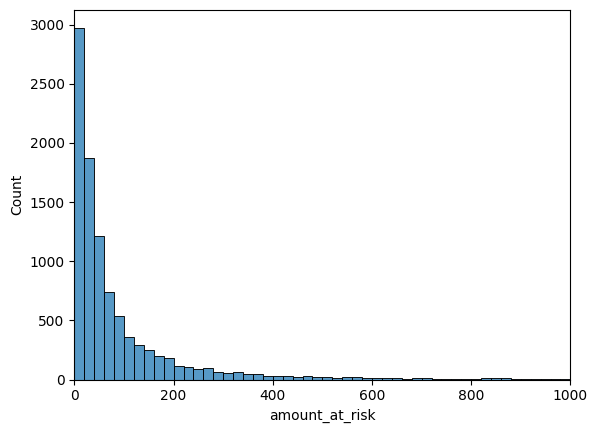

In [36]:
sample_df = df.sample(10000, random_state=42) # sampling components of our very large dataset

sns.histplot(sample_df["amount_at_risk"], bins=50, binrange=(0, 1000))
plt.xlim(0, 1000)

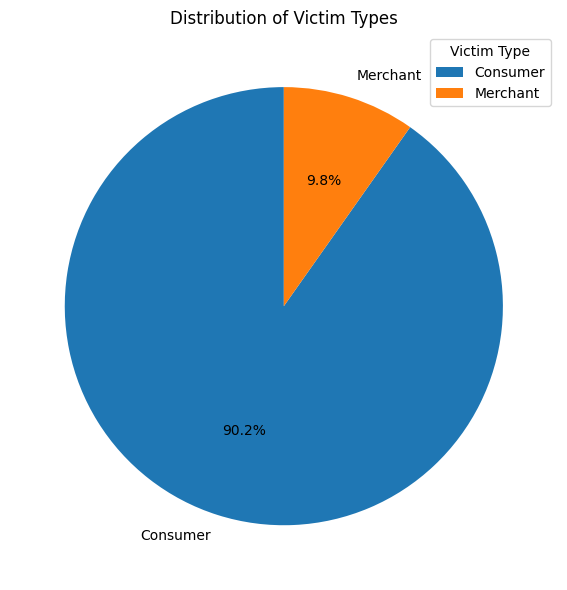

In [37]:
counts = sample_df.groupby('victim_type').size()

plt.figure(figsize=(6, 6))

counts.plot(
    kind='pie',
    autopct='%1.1f%%',     
    startangle=90,         
    ylabel='',             
)

plt.title("Distribution of Victim Types")

plt.legend(
    title="Victim Type",
    loc="best"
)

plt.tight_layout()
plt.show()

<Axes: xlabel='trigger_reason'>

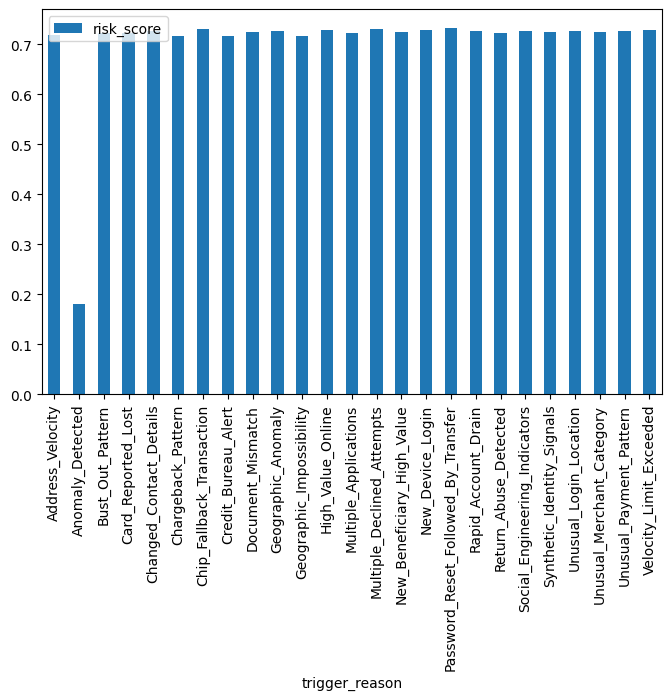

In [38]:
grouped_df = df.groupby("trigger_reason")["risk_score"].mean().reset_index()

grouped_df.plot(
    kind='bar',
    x='trigger_reason',
    y='risk_score',
    figsize=(8,5)
)



# Splitting our data

In [39]:
X = df.drop("fraud_label", axis=1)
y = df["fraud_label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Performing encoding on training set


In [40]:
categorical_columns = ['event_type','trigger_reason', 'detection_method', 'victim_type']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit ONLY on training data
encoded_train = encoder.fit_transform(X_train[categorical_columns])
encoded_test = encoder.transform(X_test[categorical_columns])

In [41]:
train_encoded_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_train_enc = pd.concat([X_train.drop(categorical_columns, axis=1), train_encoded_df], axis=1)
X_test_enc = pd.concat([X_test.drop(categorical_columns, axis=1), test_encoded_df], axis=1)

# Plotting correlation between features

/tmp/ipykernel_5045/4115884385.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  res = X_train_enc.corr(method='spearman')


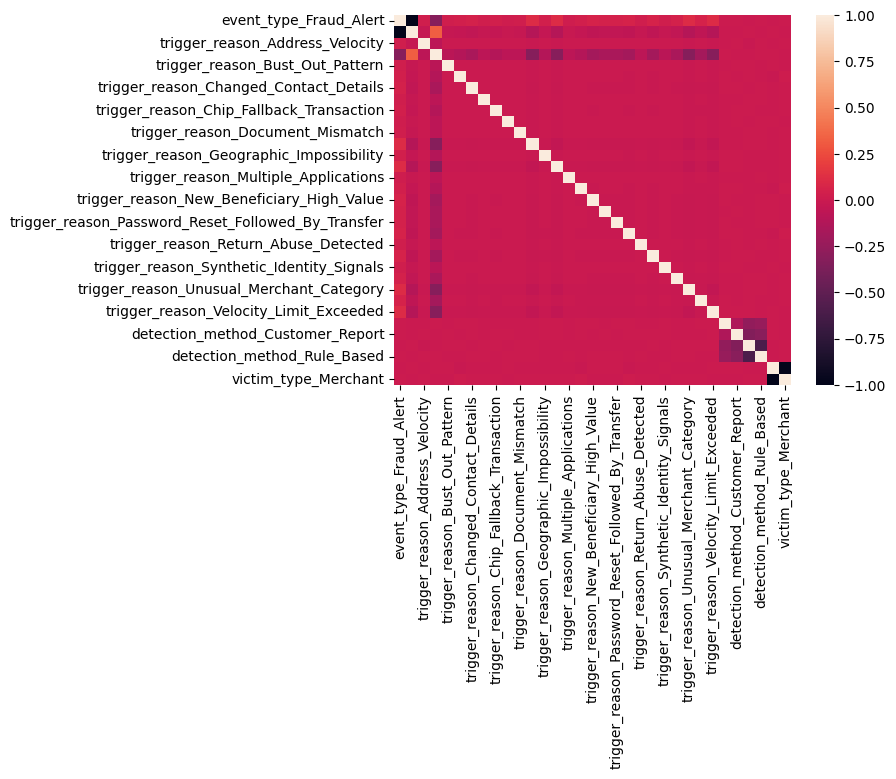

In [42]:
res = X_train_enc.corr(method='spearman')
dataplot = sns.heatmap(res)

# PCA Analysis
- Finding the elbow of the explained variance in the data (10 components) and reducing dimensions to that

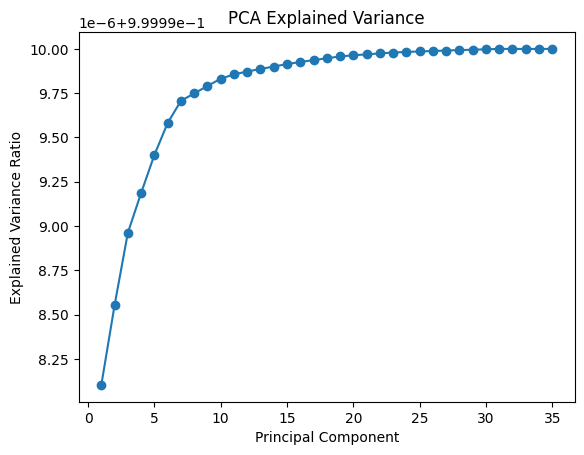

In [60]:
pca = PCA()
pca.fit(X_train_enc)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure()

plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')

plt.show()

# Ridge regression

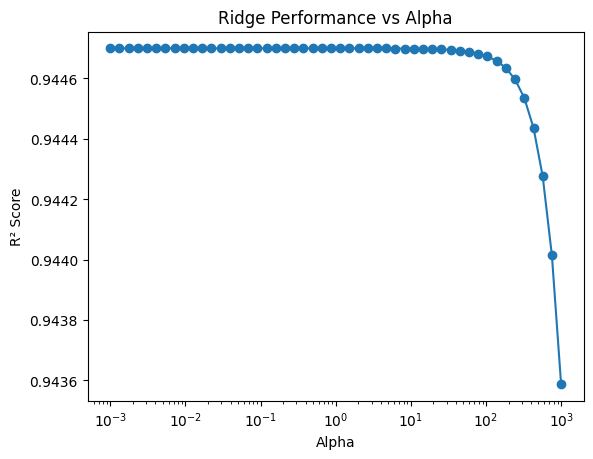

In [54]:
alphas = np.logspace(-3, 3, 50)
scores = []

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_enc, y_train_enc)
    y_pred = model.predict(X_test_enc)
    scores.append(r2_score(y_test_enc, y_pred))

plt.figure()
plt.plot(alphas, scores, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('R² Score')
plt.title('Ridge Performance vs Alpha')
plt.show()

# Lasso

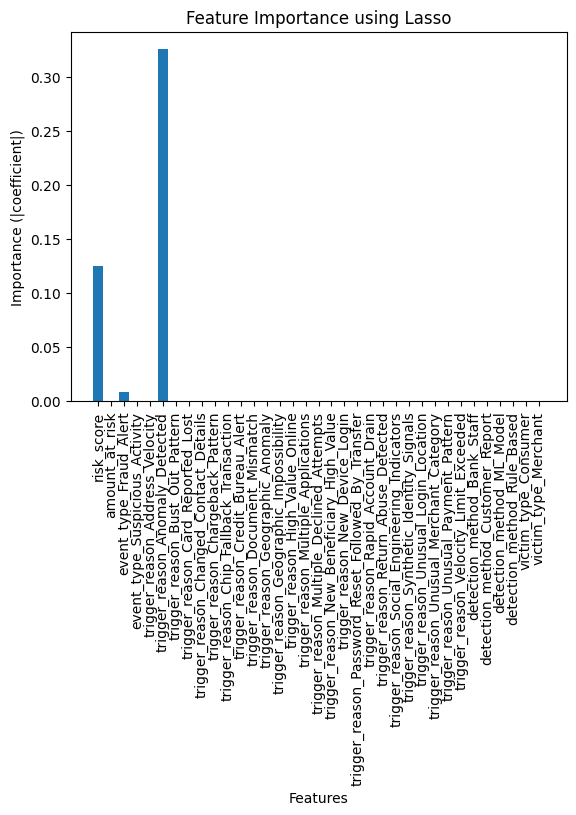

Non-zero coefficients: 4
Max coefficient: 0.3256118375561409


In [56]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_enc)

model = Lasso(alpha=0.001)
model.fit(X_scaled, y_train_enc)

# Get feature importance
importance = np.abs(model.coef_)

feature_names = X_train_enc.columns  

# Plot
plt.figure()
plt.bar(feature_names, importance)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance (|coefficient|)')
plt.title('Feature Importance using Lasso')
plt.show()
print("Non-zero coefficients:", np.sum(model.coef_ != 0))
print("Max coefficient:", np.max(np.abs(model.coef_)))

# Linear Discriminant Analysis

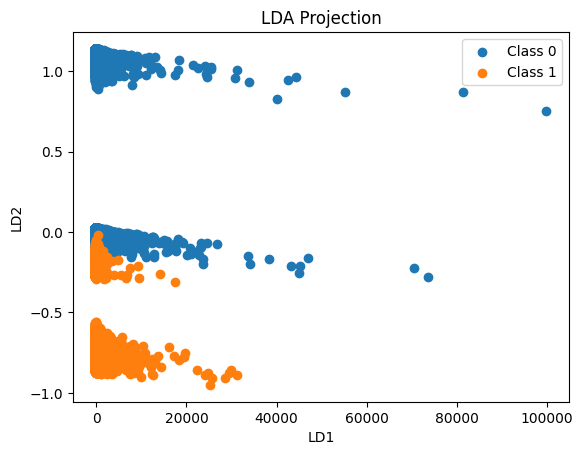

In [57]:
lda = PCA()
X_lda = lda.fit_transform(X_train_enc, y_train)


plt.figure()

for label in np.unique(y_train):
    plt.scatter(X_lda[y_train == label, 0],
                X_lda[y_train == label, 1],
                label=f'Class {label}')

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.title('LDA Projection')
plt.show()


In [ ]:
categorical_cols = ['event_type','trigger_reason', 'detection_method', 'victim_type']
numeric_cols = ["risk_score","amount_at_risk"]
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

def make_pipeline(model):
    return Pipeline([
        ('preprocessing', preprocessor),
        ('pca', PCA(n_components=10)),
        ('classifier', model)
    ])

y = y.astype(int)

In [ ]:
def heatmap(cm, title):
    sns.heatmap(cm, 
            annot=True,
            fmt='g', 
            xticklabels=['Positive','Negative'],
            yticklabels=['Positive','Negative'])
    plt.ylabel('Actual', fontsize=13)
    plt.xlabel('Prediction', fontsize=13)
    plt.title(title, fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top') 
    plt.gca().xaxis.tick_top()

    plt.gca().figure.subplots_adjust(bottom=0.2)
    plt.show()

In [ ]:
# init test df for auc-roc
test_df = pd.DataFrame({'True': y})

In [ ]:
# init dict for obtaining best recall
recalls = {}

# Performing k fold cross validation using different model types

In [71]:
scoring = ['accuracy', 'precision', 'recall', 'f1']
roc_proba_store = {}  # stores cv probabilities per model for ROC/PR curves

def perform_k_fold(pipeline, title):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = cross_validate(pipeline, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    y_pred  = cross_val_predict(pipeline, X, y, cv=kf)

    # Store probabilities for ROC/PR curves if supported
    try:
        y_proba = cross_val_predict(pipeline, X, y, cv=kf, method='predict_proba')[:, 1]
        roc_proba_store[title] = y_proba
    except Exception:
        roc_proba_store[title] = None

    cm = confusion_matrix(y, y_pred)
    heatmap(cm, title)
    test_df[title] = y_pred
    recalls[title] = results['test_recall']

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {title}')
    print(sep)
    print(f"  Accuracy  per fold: {results['test_accuracy'].round(3)}  -> mean {results['test_accuracy'].mean():.4f}")
    print(f"  Precision per fold: {results['test_precision'].round(3)}  -> mean {results['test_precision'].mean():.4f}")
    print(f"  Recall    per fold: {results['test_recall'].round(3)}  -> mean {results['test_recall'].mean():.4f}")
    print(f"  F1        per fold: {results['test_f1'].round(3)}  -> mean {results['test_f1'].mean():.4f}")


### SVC

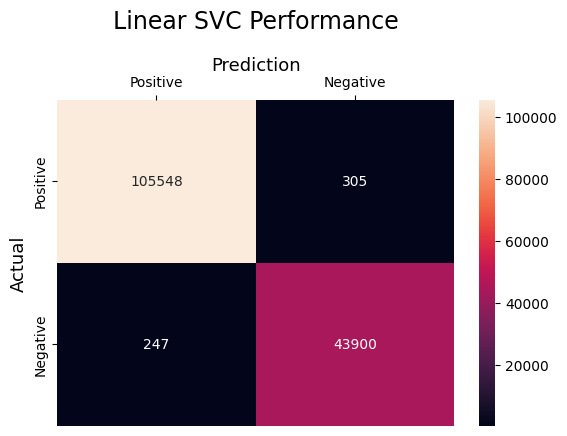


  Linear SVC Performance
  Accuracy  per fold: [0.997 0.997 0.996 0.996 0.996]  -> mean 0.9963
  Precision per fold: [0.993 0.994 0.991 0.993 0.993]  -> mean 0.9931
  Recall    per fold: [0.995 0.994 0.995 0.993 0.995]  -> mean 0.9944
  F1        per fold: [0.994 0.994 0.993 0.993 0.994]  -> mean 0.9938


In [72]:
from scipy.stats import loguniform

svc_pipeline = make_pipeline(SVC(kernel='rbf',class_weight='balanced'))
perform_k_fold(svc_pipeline, "Linear SVC Performance")

### Random forest 

In [ ]:
forest_classifier = make_pipeline(RandomForestClassifier(n_estimators=100, max_depth=10,class_weight='balanced'))
perform_k_fold(forest_classifier, 'Random Forest Performance')

### neural network

In [ ]:
nn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', MLPClassifier(random_state=42))
])

In [ ]:
param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam', 'sgd'],
    'classifier__max_iter': [200, 300]
}

random_search = RandomizedSearchCV(
    nn_pipeline,  
    param_distributions=param_grid, 
    n_iter=10,       
    cv=5,            
    n_jobs=-1,       
    random_state=42,
    verbose=2        
)
random_search.fit(X, y)
print("Best score:", random_search.best_score_)
print("Best hyperparameters:", random_search.best_params_)

In [ ]:
best_nn = random_search.best_estimator_
perform_k_fold(best_nn, 'Neural Network Performance')

### Logistic regression

In [77]:
logistic_classifier = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])


In [78]:
grid_params = {
    'classifier__solver': ['saga'],  
    'classifier__penalty': ['l1'],  
    'classifier__C': [1, 10],        
    'classifier__fit_intercept': [True, False]
}
random_search = RandomizedSearchCV(
    logistic_classifier,       
    param_distributions=grid_params,  
    n_iter=10,                 
    cv=3,                     
    n_jobs=-1,                 
    random_state=42,
    verbose=2
)
random_search.fit(X, y)
print("Best score:", random_search.best_score_)
print("Best hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_search.py:307: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1, classifier__fit_intercept=True, classifier__penalty=l1, classifier__solver=saga; total time=  55.0s


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1, classifier__fit_intercept=True, classifier__penalty=l1, classifier__solver=saga; total time=  55.8s
[CV] END classifier__C=1, classifier__fit_intercept=False, classifier__penalty=l1, classifier__solver=saga; total time=  55.0s


...

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__fit_intercept=False, classifier__penalty=l1, classifier__solver=saga; total time=  56.2s


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__fit_intercept=True, classifier__penalty=l1, classifier__solver=saga; total time= 1.1min
Best score: 0.9961333333333334
Best hyperparameters: {'classifier__solver': 'saga', 'classifier__penalty': 'l1', 'classifier__fit_intercept': True, 'classifier__C': 1}


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which 

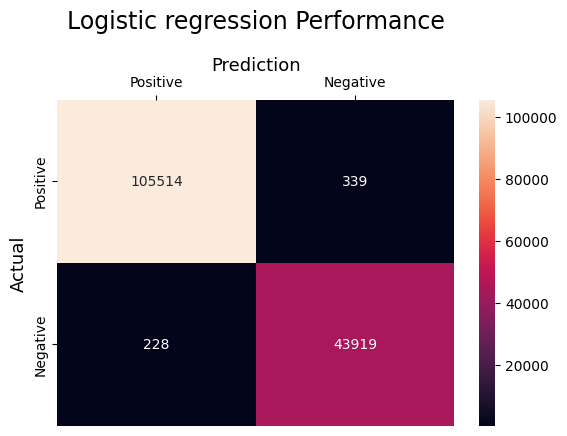


  Logistic regression Performance
  Accuracy  per fold: [0.996 0.997 0.996 0.996 0.996]  -> mean 0.9962
  Precision per fold: [0.992 0.994 0.99  0.993 0.992]  -> mean 0.9923
  Recall    per fold: [0.996 0.994 0.995 0.994 0.995]  -> mean 0.9948
  F1        per fold: [0.994 0.994 0.992 0.993 0.994]  -> mean 0.9936


In [79]:
best_regression = random_search.best_estimator_
perform_k_fold(best_regression, 'Logistic regression Performance')

### KNN

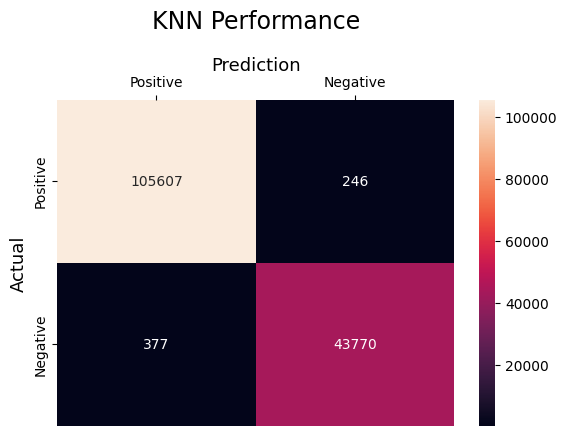


  KNN Performance
  Accuracy  per fold: [0.996 0.996 0.996 0.996 0.996]  -> mean 0.9958
  Precision per fold: [0.995 0.996 0.993 0.994 0.994]  -> mean 0.9944
  Recall    per fold: [0.992 0.992 0.992 0.99  0.992]  -> mean 0.9915
  F1        per fold: [0.993 0.994 0.993 0.992 0.993]  -> mean 0.9929


In [80]:
knn_classifier = make_pipeline(
    KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'  
    )
)

perform_k_fold(knn_classifier, 'KNN Performance')

# Model Evaluation — Summary
Consolidated precision, recall, F1 and ROC-AUC for every model.
All metrics are derived from 5-fold stratified cross-validation predictions — not the training set.

In [ ]:
import pandas as pd
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, classification_report
)

MODEL_NAMES = [
    'Linear SVC Performance',
    'Random Forest Performance',
    'Neural Network Performance',
    'Logistic regression Performance',
    'KNN Performance',
]

rows = []
for name in MODEL_NAMES:
    if name not in test_df.columns:
        continue
    y_pred = test_df[name]
    row = {
        'Model':     name.replace(' Performance', ''),
        'Accuracy':  round(accuracy_score(y, y_pred), 4),
        'Precision': round(precision_score(y, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y, y_pred), 4),
        'F1':        round(f1_score(y, y_pred), 4),
    }
    proba = roc_proba_store.get(name)
    row['ROC-AUC'] = round(roc_auc_score(y, proba), 4) if proba is not None else 'N/A'
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')
print('\n=== Cross-validated model comparison ===')
print(summary_df.to_string())


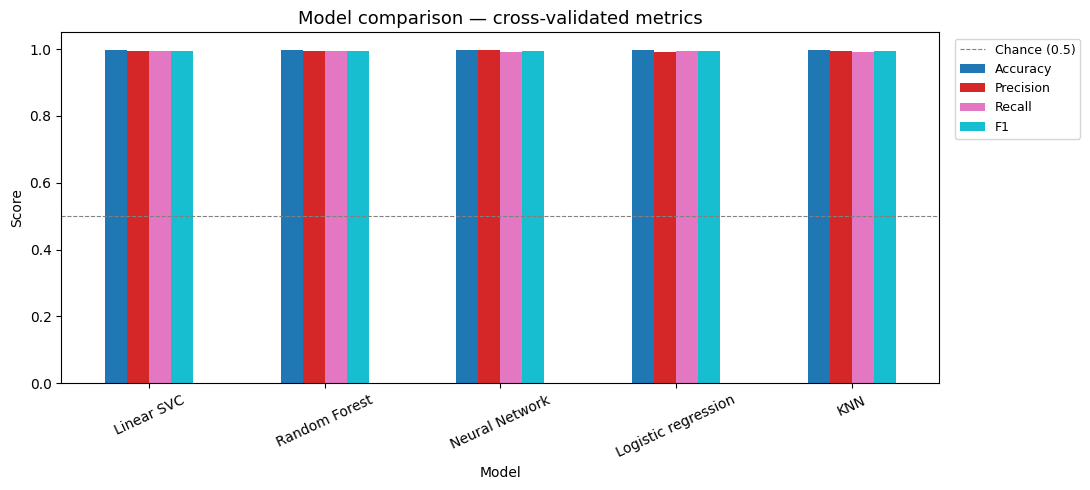

In [82]:
fig, ax = plt.subplots(figsize=(11, 5))
metric_cols = [c for c in ['Accuracy','Precision','Recall','F1'] if c in summary_df.columns]
summary_df[metric_cols].plot(kind='bar', ax=ax, rot=25, colormap='tab10')
ax.set_title('Model comparison — cross-validated metrics', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Chance (0.5)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


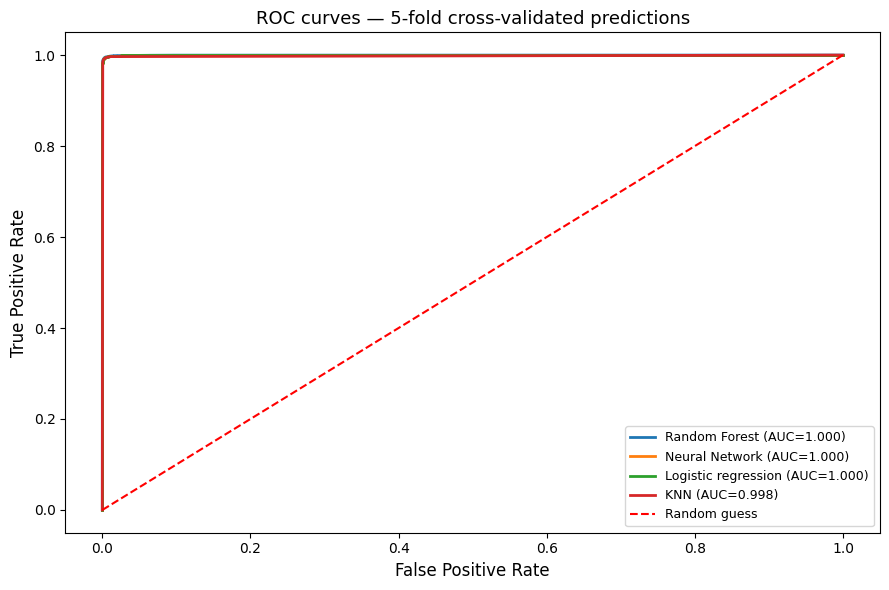

In [83]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))
for name in MODEL_NAMES:
    proba = roc_proba_store.get(name)
    if proba is None:
        continue
    fpr, tpr, _ = roc_curve(y, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name.replace(' Performance','')} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],'r--',label='Random guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC curves — 5-fold cross-validated predictions', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


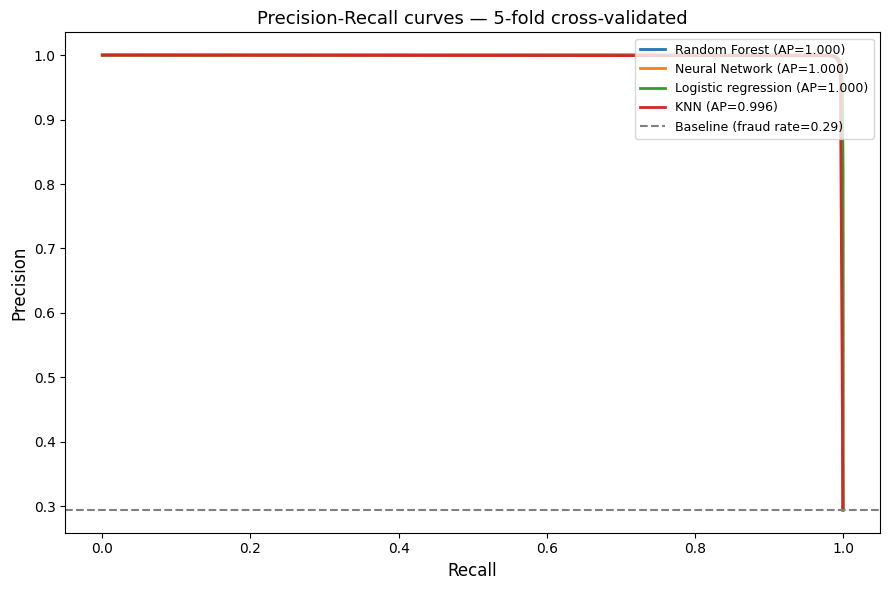

In [84]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9, 6))
for name in MODEL_NAMES:
    proba = roc_proba_store.get(name)
    if proba is None:
        continue
    prec_c, rec_c, _ = precision_recall_curve(y, proba)
    ap = average_precision_score(y, proba)
    plt.plot(rec_c, prec_c, lw=2, label=f"{name.replace(' Performance','')} (AP={ap:.3f})")
baseline = float(y.mean())
plt.axhline(baseline, color='gray', linestyle='--', label=f'Baseline (fraud rate={baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall curves — 5-fold cross-validated', fontsize=13)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


In [85]:
for name in MODEL_NAMES:
    if name not in test_df.columns:
        continue
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {name}')
    print(sep)
    print(classification_report(
        y, test_df[name],
        target_names=['Legitimate', 'Fraud'],
        digits=4
    ))



  Linear SVC Performance
              precision    recall  f1-score   support

  Legitimate     0.9977    0.9971    0.9974    105853
       Fraud     0.9931    0.9944    0.9938     44147

    accuracy                         0.9963    150000
   macro avg     0.9954    0.9958    0.9956    150000
weighted avg     0.9963    0.9963    0.9963    150000


  Random Forest Performance
              precision    recall  f1-score   support

  Legitimate     0.9975    0.9972    0.9974    105853
       Fraud     0.9933    0.9941    0.9937     44147

    accuracy                         0.9963    150000
   macro avg     0.9954    0.9957    0.9956    150000
weighted avg     0.9963    0.9963    0.9963    150000


  Neural Network Performance
              precision    recall  f1-score   support

  Legitimate     0.9968    0.9982    0.9975    105853
       Fraud     0.9957    0.9924    0.9940     44147

    accuracy                         0.9965    150000
   macro avg     0.9963    0.9953    0.9958

In [86]:
# Adjust decision threshold for the best model to tune precision vs recall
best_title = max(averages, key=averages.get)
proba = roc_proba_store.get(best_title)

if proba is not None:
    print(f'Threshold analysis for: {best_title}')
    print(f"{'Threshold':>10}  {'Accuracy':>9}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'FP':>6}  {'FN':>6}")
    print('-' * 70)
    for thresh in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
        preds = (proba >= thresh).astype(int)
        fp = int(((preds == 1) & (y == 0)).sum())
        fn = int(((preds == 0) & (y == 1)).sum())
        print(
            f'{thresh:>10.2f}  '
            f'{accuracy_score(y, preds):>9.4f}  '
            f'{precision_score(y, preds, zero_division=0):>10.4f}  '
            f'{recall_score(y, preds):>8.4f}  '
            f'{f1_score(y, preds):>8.4f}  '
            f'{fp:>6}  {fn:>6}'
        )
else:
    print(f'{best_title} does not support predict_proba — threshold tuning skipped.')


NameError: name 'averages' is not defined

# Finding our best model 

In [ ]:
recalls

In [ ]:
averages = {model: np.mean(scores) for model, scores in recalls.items()}

In [ ]:
best_model = max(averages, key=averages.get)
print(best_model, averages[best_model])

# Model Selection
- since the logistic regression model has the best average recall, we can choose that

In [ ]:
final_model = best_regression.fit(X, y)

In [ ]:
import pickle

# save
with open('fraud_classifier_eval.pkl','wb') as f:
    pickle.dump(best_regression,f)

In [ ]:
print(X)

In [ ]:
print(y)